## What is Micrograd ?
An Autograd engine that implements backpropagation over a dynamically built DAG.

In [20]:
import math
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline 
import random
#no need as of now 

In [9]:
def g(x):
    return 2*x**3 - 7*x + 4

In [10]:
g(3.0)

37.0

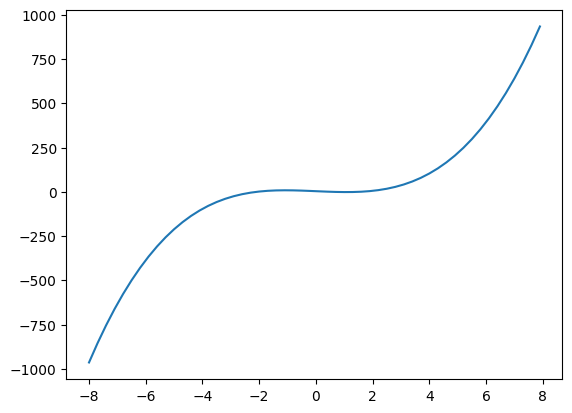

In [11]:
x = np.arange(-8,8,0.3)
y = g(x)
plt.plot(x,y)

In [12]:
h = 0.00001
xc = 2.5
(g(xc+h)-g(xc))/h

30.500150000278833

In [15]:
# for multivariables 
p = 4.0
q = 2.0
r = -3.0
z = r*q - p
print(z)

-10.0


In [16]:
h = 0.0001
p = 4.0
q = 2.0
r = -3.0

z1 = r*q - p
q += h
z2 = r*q - p

print((z2-z1)/h)

-3.000000000010772


In [9]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None 
    def __repr__(self):
        out = f"Value(data={self.data})"
        return out
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        
        return out
    # lly to rmul radd
    def __radd__(self,other):
        return self + other
    # for substraction
    def __neg__(self):
        return self * (-1)
    def __sub__(self,other):
        return self + (-other)
    # this __rmul__ is reverse multiplication if x.__mul__(y) doesn't work then python calls y.__rmul__(x).
    def __rmul__(self, other):
        return self * other
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
            
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other**-1)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad += out.grad * other * (self.data**(other - 1))
        out._backward = _backward
    
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.grad * out.data 
        out._backward = _backward    
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 -t**2) * out.grad
        out._backward = _backward
        
        return out
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [163]:
from graphviz import Digraph

def trace(root):
    
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    if n.label=='':
        # made a modification for graph viz
        dot.node(name = uid, label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
    else:    
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

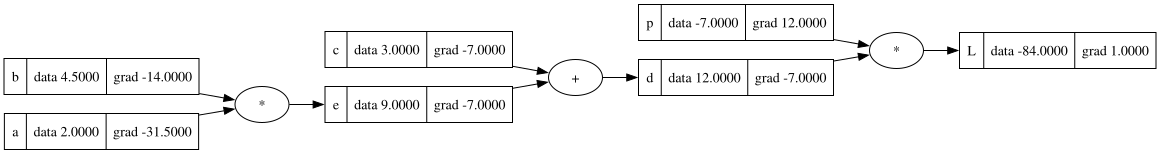

In [89]:
draw_dot(L)

In [88]:
L.backward()

In [74]:
def meow():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(4.5, label='b')
    c = Value(3.0, label='c')
    
    e = a*b; e.label='e'
    d = e + c; d.label='d'
    p = Value(-7.0, label='p')
    L = d * p; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(4.5, label='b')
    c = Value(3.0, label='c')
    
    e = a*b; e.label='e'
    e.data += h
    d = e + c; d.label='d'
    #d.data += h
    p = Value(-7.0, label='p')
    L = d * p; L.label='L'
    L2 = L.data

    print( (L2 - L1)/h )

meow()

-6.999999999990791


In [135]:
# manual backpropagation
a.grad = -31.5
b.grad = -14
c.grad = -7
d.grad = -7
e.grad = -7
L.grad = 1
p.grad = 12

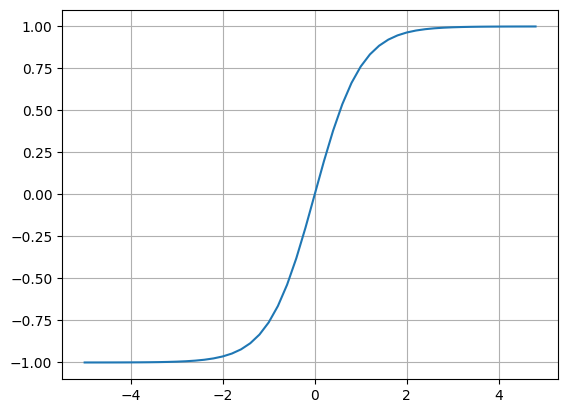

In [78]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [115]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

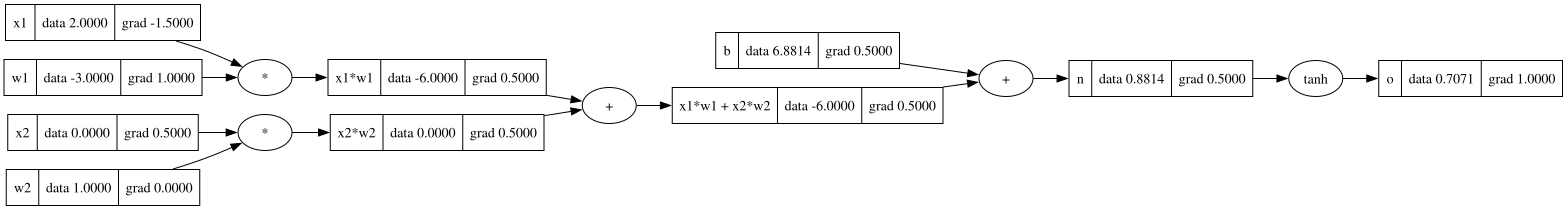

In [118]:
draw_dot(o)

In [117]:
# automatic backpropagation !
o.grad = 1.0
o.backward()

In [120]:
# topological sort 
# A topological sort is a linear ordering of vertices in a directed acyclic graph 
# For every directed edge from vertex u to vertex v, vertex u comes before v 
# in the ordering.

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

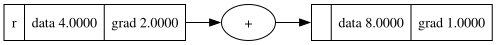

In [133]:
# the bug 
# corrected by making the grads accumulating
r = Value(4.0, label='a')
u = r + r; r.label='r'
u.backward()
draw_dot(u)

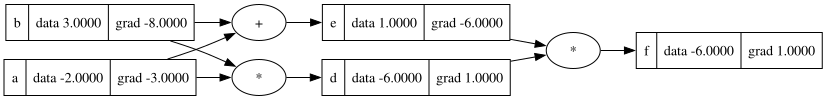

In [139]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

In [151]:
a = Value(6.0)
print(a + 1)
print(a * 3)
# 2 * a to work we use __rmul__ 
print(2 * a)

Value(data=7.0)
Value(data=18.0)
Value(data=12.0)


In [154]:
a = Value(10.0)
b = Value(4.0)
a/b

Value(data=2.5)

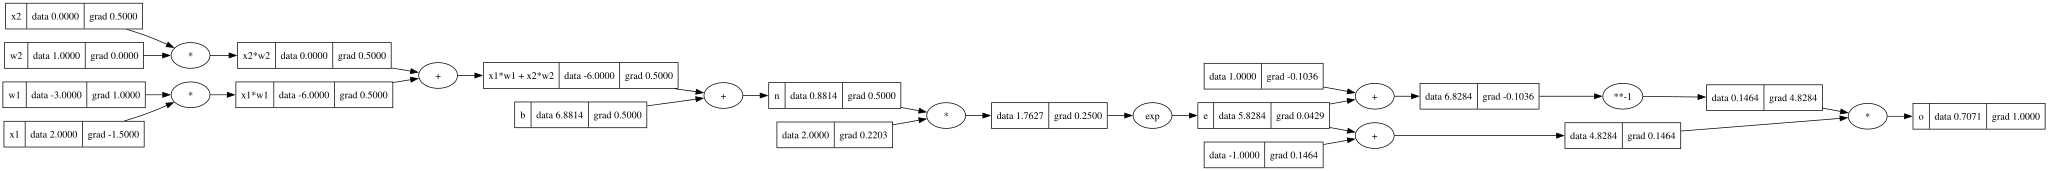

In [162]:
#breaking into still
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [14]:
import torch

In [15]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [19]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [21]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.3806031274572493)

In [22]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [23]:
for k in range(20):
  
  yreq = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, yreq))
  
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)  

0 4.365963932970894
1 1.0282275884372714
2 0.04631492012039495
3 0.03482591812762503
4 0.029373922619682497
5 0.02593116597673037
6 0.023464632358632213
7 0.021563601946813914
8 0.020027456881491164
9 0.018744864248907922
10 0.017648266244565766
11 0.016693828535095497
12 0.015851579418411418
13 0.015100143302558093
14 0.014423739064232343
15 0.013810376238407491
16 0.01325072197954758
17 0.012737362005099572
18 0.012264302546392875
19 0.011826625008495528


In [24]:
yreq

[Value(data=0.9529358133452327),
 Value(data=-0.9509254136194925),
 Value(data=-0.9445114613897323),
 Value(data=0.9357793304496155)]